#BA 305 Project Notebook

Welcome to our project notebook. For our dataset, we have worked on a steam games dataset. Each row represents a game with information about it that can be found on the game's page on steam.

##General Dataset Infromation##

##Information for each game

##Project Objective

##Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import *
%matplotlib inline
import matplotlib.pylab as plt

from sklearn import preprocessing
from sklearn.decomposition import PCA

import seaborn as sns



# mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Data Pre-Processing**

When defining the dataset into a data frame some of the columns were misplaced, so we resolved the issue with the code below.

In [ ]:
#Define the dataframe
df = pd.read_csv('/content/drive/MyDrive/games.csv')
df.head()

#Rename the columns for data consistencty
steam_df = df.rename(columns = {'AppID' : 'Name', 'Name' : 'Release date', 'Release date' : 'Estimated owners',
'Estimated owners' : 'Peak CCU', 'Peak CCU' : 'Required age', 'Required age' : 'Price', 'Price' : 'Discount',
'DiscountDLC count' : 'DLC count'})


#Remove rows where both positive and negative columns are neagtive
steam_df = steam_df[~((steam_df['Positive'] == 0) & (steam_df['Negative'] == 0))]

#Force pandas to display all the columns
pd.set_option('display.max_columns', None)

#Show the head of the dataset
steam_df.head()

,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,Supported languages,Full audio languages,Reviews,Header image,Website,Support url,Support email,Windows,Mac,Linux,Metacritic score,Metacritic url,User score,Positive,Negative,Score rank,Achievements,Recommendations,Notes,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
20200,Galactic Bowling,"Oct 21, 2008",0 - 20000,0,0,19.99,0,0,Galactic Bowling is an exaggerated and stylize...,['English'],[],NaN,https://cdn.akamai.steamstatic.com/steam/apps/...,http://www.galacticbowling.net,NaN,NaN,True,False,False,0,NaN,0,6,11,NaN,30,0,NaN,0,0,0,0,Perpetual FX Creative,Perpetual FX Creative,"Single-player,Multi-player,Steam Achievements,...","Casual,Indie,Sports","Indie,Casual,Sports,Bowling",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
655370,Train Bandit,"Oct 12, 2017",0 - 20000,0,0,0.99,0,0,THE LAW!! Looks to be a showdown atop a train....,"['English', 'French', 'Italian', 'German', 'Sp...",[],NaN,https://cdn.akamai.steamstatic.com/steam/apps/...,http://trainbandit.com,NaN,support@rustymoyher.com,True,True,False,0,NaN,0,53,5,NaN,12,0,NaN,0,0,0,0,Rusty Moyher,Wild Rooster,"Single-player,Steam Achievements,Full controll...","Action,Indie","Indie,Action,Pixel Graphics,2D,Retro,Arcade,Sc...",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
1355720,Henosis™,"Jul 23, 2020",0 - 20000,0,0,5.99,0,0,HENOSIS™ is a mysterious 2D Platform Puzzler w...,"['English', 'French', 'Italian', 'German', 'Sp...",[],NaN,https://cdn.akamai.steamstatic.com/steam/apps/...,https://henosisgame.com/,https://henosisgame.com/,info@henosisgame.com,True,True,True,0,NaN,0,3,0,NaN,0,0,NaN,0,0,0,0,Odd Critter Games,Odd Critter Games,"Single-player,Full controller support","Adventure,Casual,Indie","2D Platformer,Atmospheric,Surreal,Mystery,Puzz...",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
1139950,Two Weeks in Painland,"Feb 3, 2020",0 - 20000,0,0,0.00,0,0,ABOUT THE GAME Play as a hacker who has arrang...,"['English', 'Spanish - Spain']",[],NaN,https://cdn.akamai.steamstatic.com/steam/apps/...,https://www.unusual-games.com/home/,https://www.unusual-games.com/contact/,welistentoyou@unusual-games.com,True,True,False,0,NaN,0,50,8,NaN,17,0,This Game may contain content not appropriate ...,0,0,0,0,Unusual Games,Unusual Games,"Single-player,Steam Achievements","Adventure,Indie","Indie,Adventure,Nudity,Violent,Sexual Content,...",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...
1469160,Wartune Reborn,"Feb 26, 2021",50000 - 100000,68,0,0.00,0,0,Feel tired of auto-fight? Feel tired of boring...,['English'],[],NaN,https://cdn.akamai.steamstatic.com/steam/apps/...,NaN,https://7.wan.com,https://wartune@7road.com,True,False,False,0,NaN,0,87,49,NaN,0,0,NaN,0,0,0,0,7Road,7Road,"Single-player,Multi-player,MMO,PvP,Online PvP,...","Adventure,Casual,Free to Play,Massively Multip...","Turn-Based Combat,Massively Multiplayer,Multip...",https://cdn.akamai.steamstatic.com/steam/apps/...,http://cdn.akamai.steamstatic.com/steam/apps/2...


We created a correlation matrix to make sure we did not have a problem of multicollinerity between our predictors

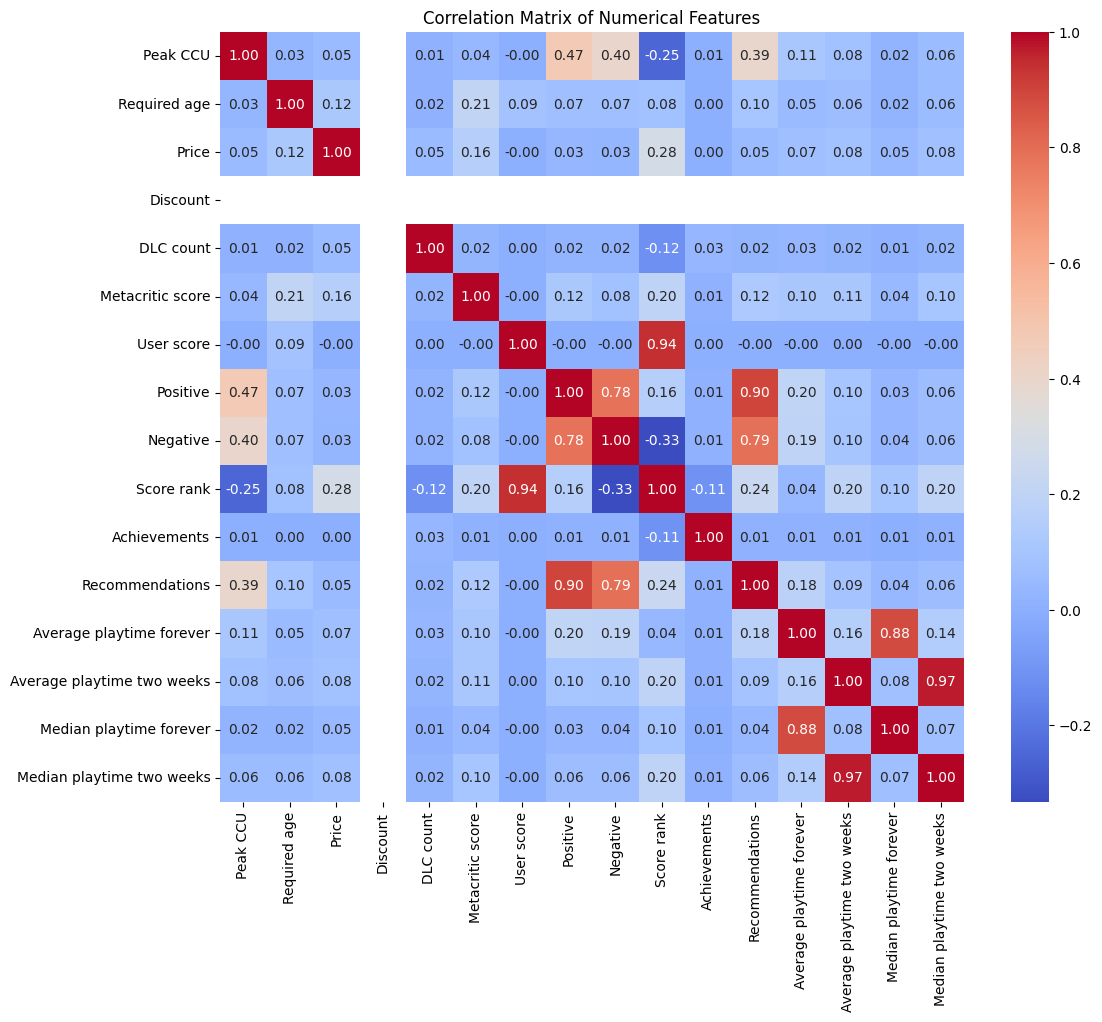

In [ ]:
# Defining seperate lists for numerical and categorical columns of steam_df
numerical_cols = steam_df.select_dtypes(include=['number']).columns
categorical_cols = steam_df.select_dtypes(exclude=['number']).columns

# Drop categorical columns
steam_df_numerical = steam_df.drop(columns=categorical_cols)

# Calculate correlation matrix
correlation_matrix = steam_df_numerical.corr()


# Create a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## **Data Cleaning**

This is our 3rd iteration of Data cleaning for this dataset. For this dataset, we asked ChatGPT to crate some columns so that we could potentially get better prediction results on our models. Furthemore, we used ChatGPT to help transform our About the Game and Notes columns to further help with our prediction results.The columns we asked Chatgpt to create were Development time(how long the game took to develop), Game Budget(whether the game was AAA(high-end), AA(medium-tier), or Indie(small-scale), Estimated Runtime, Ad Quality Score(0-10), Controller Support(if the game supports a controller) and Difficutly(Easy, Medium, Hard).

###Adding new columns and new transformations from Chatgpt

The first transformation we decided to do was for the about the games column. In our previous iterations, we did not find a proper way to transform this column, so here, we decided to ask ChatGPT to evaluate the writing quality for the each about the game observation, and give out a floating number between 0 and 10.

In [ ]:
#Extract the unique values for the About the game column and export them as a CSV file
unique_about_game = steam_df['About the game'].unique()
unique_about_game_df = pd.DataFrame(unique_about_game, columns=['About the game'])
unique_about_game_df.to_csv('unique_about_game.csv', index=False)


#Merge steam_df and about_game_ratings based on about the game column
About_game_ratings=pd.read_csv('/content/drive/MyDrive/BA305 Project/Extra Datasets for Data Cleaning Iteration 3 and 4/about_the_game_with_ratings.csv')

# Merge the two dataframes based on the 'About the game' column
steam_df = pd.merge(steam_df, About_game_ratings, on='About the game', how='inner')

The second transformation was for the Notes column, because last iteration we simply gave it a 1 or 0 if there was a note or not. However, that transformation did not have a high feature importance, so we decided to try a different approach to transforming that column. We utilized the same approach as with the About the game column where we exported the unique notes values and gave it to Chatgpt to evaluate note quality, in the form of a float number between 0 and 10.  

In [ ]:
#Extract the unique values for the Notes column and export them as a CSV file
unique_notes = steam_df['Notes'].unique()
unique_notes_df = pd.DataFrame({'Unique Notes': unique_notes})
unique_notes_df.to_csv('unique_notes.csv', index=False)

#Merge steam_df and notes_with_quality_scores based on about the game column
notes_with_quality_scores=pd.read_csv('/content/drive/MyDrive/BA305 Project/Extra Datasets for Data Cleaning Iteration 3 and 4/notes_with_quality_scores.csv')

#Rename the Unique Notes column to Notes for easier merging
notes_with_quality_scores.rename(columns={'Unique Notes': 'Notes'}, inplace=True)

# Merge the two dataframes based on the 'About the game' column
steam_df = pd.merge(steam_df, notes_with_quality_scores, on='Notes', how='left')

Finally, for generating the Chatgpt columns, we exported the unique game names as a CSV file, and fed it to Chatgpt along with our prompts to create new columns. We then uploaded the csv onto the notebook and merged it with our dataset

In [ ]:
#Extract the unique values for the Name column and export them as a CSV file
unique_names = steam_df['Name'].unique()
unique_names_df = pd.DataFrame({'Name': unique_names})
unique_names_df.to_csv('unique_game_names.csv', index=False)


#Merge steam_df and chatgppt columns based on about the game column
Chat_gpt_columns=pd.read_csv('/content/drive/MyDrive/BA305 Project/Extra Datasets for Data Cleaning Iteration 3 and 4/games_with_all_extra_columns.csv')

# Merge the two dataframes based on the 'About the game' column
steam_df = pd.merge(steam_df,Chat_gpt_columns, on='Name', how='inner')

When looking through the data, we found a couple of columns which had incompatible formating with python and ones which did not matter for our analysis

###Removing Unnecessary columns and null values

When looking through our dataset, we had a few columns that we would not be able to use, such as Support Url and Screenshots, or columns with a lot of null values so we decided to drop them. Furthermore, we decided to drop all null values for now and then come back to them later.

In [ ]:
#Defining the list of columns to drop
col_to_be_dropped= ['Reviews','Website','Support url','Support email','Metacritic url','Header image','Score rank','Screenshots','Movies','Notes']

#Drop the unnecessary columns
steam_df=steam_df.drop(col_to_be_dropped,axis=1)

#Dropping the null values from the dataset
steam_df=steam_df.dropna()

#Checking if any columns still have null values
steam_df.isnull().sum()

,0
Name,0
Release date,0
Estimated owners,0
Peak CCU,0
Required age,0
Price,0
Discount,0
DLC count,0
About the game,0
Supported languages,0


###Data Transformations###

Our dataset had a lot of categorical columns which would not go well with the models we covered in class. So we decided to transform the columns in the code below

####Redefining Columns####

We created our response variable column Positive% and dropped the Positive and Negative columns since they would be highly correlated with the response variable.

In [ ]:
steam_df['Positive%'] = steam_df['Positive'] / (steam_df['Positive'] + steam_df['Negative']) * 100
steam_df=steam_df.drop(['Positive','Negative'],axis=1)
steam_df.head()

<ipython-input-8-04685b583163>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  steam_df['Positive%'] = steam_df['Positive'] / (steam_df['Positive'] + steam_df['Negative']) * 100


,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,Supported languages,Full audio languages,Windows,Mac,Linux,Metacritic score,User score,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Writing Quality Rating,Note Quality (0–10),Development Time (Months),Game Budget,Estimated Runtime(In hours),Ad Quality Score (0-10),Controller Support,Difficulty,Positive%
0,Galactic Bowling,"Oct 21, 2008",0 - 20000,0,0,19.99,0,0,Galactic Bowling is an exaggerated and stylize...,['English'],[],True,False,False,0,0,30,0,0,0,0,0,Perpetual FX Creative,Perpetual FX Creative,"Single-player,Multi-player,Steam Achievements,...","Casual,Indie,Sports","Indie,Casual,Sports,Bowling",9.2,0,12,Indie,8,4,No,Medium,35.294118
1,Train Bandit,"Oct 12, 2017",0 - 20000,0,0,0.99,0,0,THE LAW!! Looks to be a showdown atop a train....,"['English', 'French', 'Italian', 'German', 'Sp...",[],True,True,False,0,0,12,0,0,0,0,0,Rusty Moyher,Wild Rooster,"Single-player,Steam Achievements,Full controll...","Action,Indie","Indie,Action,Pixel Graphics,2D,Retro,Arcade,Sc...",8.8,0,12,Indie,8,4,No,Medium,91.379310
2,Henosis™,"Jul 23, 2020",0 - 20000,0,0,5.99,0,0,HENOSIS™ is a mysterious 2D Platform Puzzler w...,"['English', 'French', 'Italian', 'German', 'Sp...",[],True,True,True,0,0,0,0,0,0,0,0,Odd Critter Games,Odd Critter Games,"Single-player,Full controller support","Adventure,Casual,Indie","2D Platformer,Atmospheric,Surreal,Mystery,Puzz...",9.4,0,12,Indie,8,4,No,Medium,100.000000
3,Two Weeks in Painland,"Feb 3, 2020",0 - 20000,0,0,0.00,0,0,ABOUT THE GAME Play as a hacker who has arrang...,"['English', 'Spanish - Spain']",[],True,True,False,0,0,17,0,0,0,0,0,Unusual Games,Unusual Games,"Single-player,Steam Achievements","Adventure,Indie","Indie,Adventure,Nudity,Violent,Sexual Content,...",9.0,6,12,Indie,8,4,No,Medium,86.206897
4,Wartune Reborn,"Feb 26, 2021",50000 - 100000,68,0,0.00,0,0,Feel tired of auto-fight? Feel tired of boring...,['English'],[],True,False,False,0,0,0,0,0,0,0,0,7Road,7Road,"Single-player,Multi-player,MMO,PvP,Online PvP,...","Adventure,Casual,Free to Play,Massively Multip...","Turn-Based Combat,Massively Multiplayer,Multip...",9.2,0,12,Indie,8,4,No,Medium,63.970588


For publishers and developers columns we had too many unique values. We decided to create aggregate grouping based on how many games the publishers and developers made. The reasoning is that with more games made, the publishers and developers would have more experience which would translate into a theoretically better game.

In [ ]:
# Group by publisher and count the number of games
publisher_game_counts = steam_df.groupby('Publishers')['Name'].count().reset_index()
publisher_game_counts.rename(columns={'Name': 'Num games published by publisher'}, inplace=True)

# Merge the counts back into the original DataFrame
steam_df = pd.merge(steam_df, publisher_game_counts, on='Publishers', how='left')



# Group by publisher and count the number of games
publisher_game_counts = steam_df.groupby('Developers')['Name'].count().reset_index()
publisher_game_counts.rename(columns={'Name': 'Num games developed by developer'}, inplace=True)

# Merge the counts back into the original DataFrame
steam_df = pd.merge(steam_df, publisher_game_counts, on='Developers', how='left')

We have combined the Name and Estimated owners columns into one column called Large Established player base title because we felt that the biggest positive point about a game name is if there is a large player base that would play if a new game iteration would be realeased.

In [ ]:
# prompt: Create dummy variables for the estimated owners column

import pandas as pd
# Create dummy variables for the 'Estimated owners' column
estimated_owners_dummies = pd.get_dummies(steam_df['Estimated owners'], prefix='Estimated_owners')

# Concatenate the dummy variables with the original DataFrame
steam_df = pd.concat([steam_df, estimated_owners_dummies], axis=1)

# Remove the original 'Estimated owners' column
steam_df = steam_df.drop('Estimated owners', axis=1)


We also exttracted the Release month from the Release date column because we thouhgt the month a game released can have an impact towards its positive%. We then grouped into an aggregate category based on the month's season. We did this so that our models would not think 12(December) is more than (2) February and etc.

In [ ]:
# Assuming 'Release date' column contains date strings
steam_df['Release Month'] = pd.to_datetime(steam_df['Release date'], errors='coerce', format='mixed').dt.month

# Create a function to categorize release months into seasons
def categorize_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Fall'
    else:
        return 'Unknown'  # Handle potential invalid month values

# Apply the function to create a new 'Season' column
steam_df['Season'] = steam_df['Release Month'].apply(categorize_season)

We have also extracted the Release Year column to see if how old a game is has an impact on the Positive%

In [ ]:
#Extract the Year of release for the games from the Release date column
steam_df['Release Year'] = pd.to_datetime(steam_df['Release date'], errors='coerce', format='mixed').dt.year

# Calculate the 'Years old' column
steam_df['Years old'] = 2025 - steam_df['Release Year']

# Drop the original 'Release date' column
steam_df = steam_df.drop(['Release date', 'Release Year'], axis=1)

Based on our previous iteration, counting the number of categories, genres, and tags is effective so we applied that approach to here as well.

In [ ]:
# Function to process categorical columns and create 'Number of' columns
def process_categorical_column(df, column_name):
    """
    Creates a new column representing the count of elements in a categorical column.

    Args:
        df: The DataFrame.
        column_name: The name of the categorical column.
    """
    new_column_name = f"Number of {column_name.replace('_', ' ').title()}"
    df[new_column_name] = df[column_name].str.split(',').str.len()
    return df


# Apply the function to the specified columns
steam_df = process_categorical_column(steam_df, 'Categories')
steam_df = process_categorical_column(steam_df, 'Genres')
steam_df = process_categorical_column(steam_df, 'Tags')

We needed to map our Controller Support column to one-hot encoding

In [ ]:
# One-hot encode the 'Controller Support' column
steam_df['Controller Support'] = steam_df['Controller Support'].map({'No': 0, 'Yes': 1})

For our languages, we decided to try using the number supported and audio languages, just to see if they would help with our prediction

In [ ]:
# Count the number of languages and create new columns
steam_df['Number of Supported Languages'] = steam_df['Supported languages'].apply(len)
steam_df['Number of Audio Languages'] = steam_df['Full audio languages'].apply(len)

####Creating Dummy columns####

For our categorical columns, we have decided to create dummy variables for at least the most prominent categories in those columns.

We needed to create dummy variables for some of the columns generated by Chatgpt, and also for the Season column we created from the Release Month column.

In [ ]:
# Create dummy variables for 'Game_budget'
game_budget_dummies = pd.get_dummies(steam_df['Game Budget'], prefix='Game Budget')
steam_df = pd.concat([steam_df, game_budget_dummies], axis=1)
steam_df = steam_df.drop('Game Budget', axis=1)

# Create dummy variables for 'Difficulty'
difficulty_dummies = pd.get_dummies(steam_df['Difficulty'], prefix='Difficulty')
steam_df = pd.concat([steam_df, difficulty_dummies], axis=1)
steam_df = steam_df.drop('Difficulty', axis=1)

# Create dummy variables for 'Season'
season_dummies = pd.get_dummies(steam_df['Season'], prefix='Season')
steam_df = pd.concat([steam_df, season_dummies], axis=1)
steam_df = steam_df.drop('Season', axis=1)

####Dropping Columns

In [ ]:
steam_df=steam_df.drop(['Name','Supported languages','Full audio languages','Categories','Genres','Tags',
                        'Developers','Publishers','About the game','Release Month'],axis=1)

In [ ]:
print(steam_df.shape)
steam_df.head()

(67185, 54)


,Peak CCU,Required age,Price,Discount,DLC count,Windows,Mac,Linux,Metacritic score,User score,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Writing Quality Rating,Note Quality (0–10),Development Time (Months),Estimated Runtime(In hours),Ad Quality Score (0-10),Controller Support,Positive%,Num games published by publisher,Num games developed by developer,Estimated_owners_0 - 20000,Estimated_owners_100000 - 200000,Estimated_owners_1000000 - 2000000,Estimated_owners_10000000 - 20000000,Estimated_owners_100000000 - 200000000,Estimated_owners_20000 - 50000,Estimated_owners_200000 - 500000,Estimated_owners_2000000 - 5000000,Estimated_owners_20000000 - 50000000,Estimated_owners_50000 - 100000,Estimated_owners_500000 - 1000000,Estimated_owners_5000000 - 10000000,Estimated_owners_50000000 - 100000000,Years old,Number of Categories,Number of Genres,Number of Tags,Number of Supported Languages,Number of Audio Languages,Game Budget_AA,Game Budget_AAA,Game Budget_Indie,Difficulty_Easy,Difficulty_Hard,Difficulty_Medium,Season_Fall,Season_Spring,Season_Summer,Season_Winter
0,0,0,19.99,0,0,True,False,False,0,0,30,0,0,0,0,0,9.2,0,12,8,4,0,35.294118,1,1,True,False,False,False,False,False,False,False,False,False,False,False,False,17,4,3,4,11,2,False,False,True,False,False,True,True,False,False,False
1,0,0,0.99,0,0,True,True,False,0,0,12,0,0,0,0,0,8.8,0,12,8,4,0,91.379310,5,4,True,False,False,False,False,False,False,False,False,False,False,False,False,8,7,2,20,152,2,False,False,True,False,False,True,True,False,False,False
2,0,0,5.99,0,0,True,True,True,0,0,0,0,0,0,0,0,9.4,0,12,8,4,0,100.000000,1,1,True,False,False,False,False,False,False,False,False,False,False,False,False,5,2,3,19,153,2,False,False,True,False,False,True,False,False,True,False
3,0,0,0.00,0,0,True,True,False,0,0,17,0,0,0,0,0,9.0,6,12,8,4,0,86.206897,1,1,True,False,False,False,False,False,False,False,False,False,False,False,False,5,2,2,6,30,2,False,False,True,False,False,True,False,False,False,True
4,68,0,0.00,0,0,True,False,False,0,0,0,0,0,0,0,0,9.2,0,12,8,4,0,63.970588,1,1,False,False,False,False,False,False,False,False,False,True,False,False,False,4,8,6,20,11,2,False,False,True,False,False,True,False,False,False,True


## **Regression Model Testing**

Below are the models we have decided to use for our analysis.

In [ ]:
X=steam_df.drop(['Positive%'],axis=1)
y=steam_df['Positive%']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=1)

print(X.shape)
print(X.dtypes)

(67185, 53)
Peak CCU                                    int64
Required age                                int64
Price                                     float64
Discount                                    int64
DLC count                                   int64
Windows                                      bool
Mac                                          bool
Linux                                        bool
Metacritic score                            int64
User score                                  int64
Achievements                                int64
Recommendations                             int64
Average playtime forever                    int64
Average playtime two weeks                  int64
Median playtime forever                     int64
Median playtime two weeks                   int64
Writing Quality Rating                    float64
Note Quality (0–10)                         int64
Development Time (Months)                   int64
Estimated Runtime(In hours)           

###Benchmark

In [ ]:
import math
# Calculate the average of 'Positive%' in y_train
average_positive_percentage_train = y_train.mean()

# Predict all values in y_test as the average of y_train
predictions = [average_positive_percentage_train] * len(y_test)

print(average_positive_percentage_train)

# Calculate RMSE
rmse = math.sqrt(mean_squared_error(y_test, predictions))
print(f"RMSE using average of y_train: {rmse}")
print(predictions)

75.70953451700932
RMSE using average of y_train: 24.638883731349868
[np.float64(75.70953451700932), np.float64(75.70953451700932), np.float64(75.70953451700932), np.float64(75.70953451700932), np.float64(75.70953451700932), np.float64(75.70953451700932), np.float64(75.70953451700932), np.float64(75.70953451700932), np.float64(75.70953451700932), np.float64(75.70953451700932), np.float64(75.70953451700932), np.float64(75.70953451700932), np.float64(75.70953451700932), np.float64(75.70953451700932), np.float64(75.70953451700932), np.float64(75.70953451700932), np.float64(75.70953451700932), np.float64(75.70953451700932), np.float64(75.70953451700932), np.float64(75.70953451700932), np.float64(75.70953451700932), np.float64(75.70953451700932), np.float64(75.70953451700932), np.float64(75.70953451700932), np.float64(75.70953451700932), np.float64(75.70953451700932), np.float64(75.70953451700932), np.float64(75.70953451700932), np.float64(75.70953451700932), np.float64(75.70953451700932), n

###KNN-regressor

In [ ]:
from sklearn.neighbors import KNeighborsRegressor


# Standardize the data
scaler = preprocessing.StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the KNN regressor with scaled data
knn_regressor_scaled = KNeighborsRegressor(n_neighbors=20) # You can adjust the number of neighbors
knn_regressor_scaled.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_scaled = knn_regressor_scaled.predict(X_test_scaled)

# Calculate RMSE for the scaled data
rmse_scaled = math.sqrt(mean_squared_error(y_test, y_pred_scaled))
print(f"KNN RMSE (Scaled Data): {rmse_scaled}")


KNN RMSE (Scaled Data): 23.676594580092303


###Decision Trees

In [ ]:
from sklearn.tree import DecisionTreeRegressor



# Initialize and train the decision tree regressor
dt_regressor = DecisionTreeRegressor(random_state=1)  # You can tune hyperparameters here
dt_regressor.fit(X_train, y_train)

# Make predictions on the test set
y_pred = dt_regressor.predict(X_test)

# Evaluate the model
rmse = math.sqrt(mean_squared_error(y_test, y_pred))
print(f"Decision Tree RMSE: {rmse}")

# You can further tune the hyperparameters of the decision tree using GridSearchCV
# for better performance.


Decision Tree RMSE: 32.4565056012414


In [ ]:
# prompt: Can you scale the data before running decision trees?

import numpy as np
# Assuming X_train and X_test are your training and testing dataframes respectively.
# Also assuming you want to scale only the numerical features

from sklearn.preprocessing import StandardScaler

# Identify numerical features
numerical_cols = X_train.select_dtypes(include=np.number).columns

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

# Now use X_train_scaled and X_test_scaled for your decision tree model
dt_regressor = DecisionTreeRegressor(random_state=1)
dt_regressor.fit(X_train_scaled, y_train)
y_pred = dt_regressor.predict(X_test_scaled)
rmse = math.sqrt(mean_squared_error(y_test, y_pred))
print(f"Decision Tree RMSE (Scaled Data): {rmse}")


Decision Tree RMSE (Scaled Data): 32.46972885956875


In [ ]:
# prompt: Can you run a cross validation test to hypertune the parameters in the decision tree?

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'max_depth': [None, 10, 20, 30,40,50],
    'min_samples_split': [2, 5, 10,20],
    'min_samples_leaf': [1, 2, 4,8]
}

# Initialize the decision tree regressor
dt_regressor = DecisionTreeRegressor(random_state=1)

# Perform GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(estimator=dt_regressor, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train_scaled, y_train)

# Get the best hyperparameters and the best model
best_params = grid_search.best_params_
best_dt_regressor = grid_search.best_estimator_

print(f"Best Hyperparameters: {best_params}")

# Evaluate the best model on the test set
y_pred = best_dt_regressor.predict(X_test_scaled)
rmse = math.sqrt(mean_squared_error(y_test, y_pred))
print(f"Decision Tree RMSE (Scaled Data, Tuned): {rmse}")


KeyboardInterrupt: 

###Random Forest and Feature Importance

In [ ]:
# prompt: Can you run random forests on the data? and give the rmse of that?

from sklearn.ensemble import RandomForestRegressor

# Assuming X_train_scaled, X_test_scaled, y_train, and y_test are defined from previous code

# Initialize and train the random forest regressor
rf_regressor = RandomForestRegressor(random_state=1, n_estimators=100)  # You can adjust the number of estimators and other hyperparameters
rf_regressor.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_rf = rf_regressor.predict(X_test_scaled)

# Calculate RMSE for the random forest model
rmse_rf = math.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"Random Forest RMSE (Scaled Data): {rmse_rf}")


Random Forest RMSE (Scaled Data): 22.723583392122976


In [ ]:
# prompt: Can you print out the importance of each column based on the random forest above?

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import math

# Assuming X and y are defined as in the previous code
# X = steam_df_cleaned.drop('Positive%', axis=1)
# y = steam_df_cleaned['Positive%']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=1)

# Identify numerical features
numerical_cols = X_train.select_dtypes(include=np.number).columns

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

# Initialize and train the random forest regressor
rf_regressor = RandomForestRegressor(random_state=1, n_estimators=100)  # You can adjust the number of estimators and other hyperparameters
rf_regressor.fit(X_train_scaled, y_train)

# Get feature importances
importances = rf_regressor.feature_importances_

# Create a DataFrame to display feature importances
feature_importances = pd.DataFrame({'Feature': X_train_scaled.columns, 'Importance': importances})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
feature_importances


In [ ]:
# prompt: Can you visualize out the feature importances?

import matplotlib.pyplot as plt

# Assuming feature_importances DataFrame is defined as in the previous code

plt.figure(figsize=(30, 20))
plt.barh(feature_importances['Feature'], feature_importances['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importances")
plt.gca().invert_yaxis()  # Invert y-axis to display the most important features at the top
plt.show()


###Linear Regression

In [ ]:
# prompt: Can you also run a linear regression model and determine its rmse?(be sure to scale the data again)

from sklearn.linear_model import LinearRegression

# Assuming X_train_scaled, X_test_scaled, y_train, and y_test are defined from previous code

# Initialize and train the linear regression model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_lr = lr_model.predict(X_test_scaled)

# Calculate RMSE for the linear regression model
rmse_lr = math.sqrt(mean_squared_error(y_test, y_pred_lr))
print(f"Linear Regression RMSE (Scaled Data): {rmse_lr}")


Linear Regression RMSE (Scaled Data): 23.609925889044153


###XGboost

In [ ]:
# prompt: Can you apply the XGboost model now?and show the rmse please

!pip install xgboost

import xgboost as xgb
from sklearn.metrics import mean_squared_error
import math

# Assuming X_train_scaled, X_test_scaled, y_train, and y_test are defined from previous code

# Initialize and train the XGBoost regressor
xgb_regressor = xgb.XGBRegressor(objective='reg:squarederror', random_state=1) # Use reg:squarederror for regression
xgb_regressor.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_regressor.predict(X_test_scaled)

# Calculate RMSE for the XGBoost model
rmse_xgb = math.sqrt(mean_squared_error(y_test, y_pred_xgb))
print(f"XGBoost RMSE (Scaled Data): {rmse_xgb}")


###Nueral Network

In [ ]:
# prompt: Can you now apply a neural network model while also showing the rmse?(Using mlpregressor)

from sklearn.neural_network import MLPRegressor

# Assuming X_train_scaled, X_test_scaled, y_train, and y_test are defined from previous code

# Initialize and train the MLPRegressor
mlp_regressor = MLPRegressor(hidden_layer_sizes=(10), max_iter=1000, activation='logistic',solver='lbfgs', random_state=1) # Adjust hidden_layer_sizes and other hyperparameters as needed
mlp_regressor.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_mlp = mlp_regressor.predict(X_test_scaled)

# Calculate RMSE for the MLPRegressor model
rmse_mlp = math.sqrt(mean_squared_error(y_test, y_pred_mlp))
print(f"MLPRegressor RMSE (Scaled Data): {rmse_mlp}")


MLPRegressor RMSE (Scaled Data): 23.131966508316328


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
